# IBM HR Analytics: Attrition Prediction
**Goal:** Analyze employee data to discover why employees are leaving the company.

### Project Roadmap
- [x] **Phase 1: Setup & Load Data**
- [x] **Phase 2: Data Inspection** (Understanding the structure)
- [x] **Phase 3: Data Cleaning** (Fixing missing/messy data)
- [x] **Phase 4: Exploratory Data Analysis** (Visualizing trends)
- [x] **Phase 5: Conclusion** (Summarizing business insights)

In [1]:
# 1. Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Set up visualization styles (makes your charts look professional instantly)
sns.set_theme(style="whitegrid")
plt.style.use("fivethirtyeight")

# 3. Load the dataset
# Note: In Kaggle, your file path will usually look like this. 
# If it throws an error, you can copy the exact file path by clicking the three dots 
# next to your file in the right-hand 'Data' panel and selecting 'Copy file path'.
file_path = '/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv' 
df = pd.read_csv(file_path)

# 4. Display the first 5 rows to confirm it loaded correctly
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# 1. Check the size of the dataset (Rows, Columns)
print(f"Dataset Shape: {df.shape}\n")
print("-" * 40)

# 2. Check for exact duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}\n")
print("-" * 40)

# 3. Check for missing values in every column
missing_values = df.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0]) # This only prints columns that actually have missing data
print("-" * 40)

# 4. Look at the data types (integers, strings/objects, floats)
df.info()

Dataset Shape: (1470, 35)

----------------------------------------
Number of duplicate rows: 0

----------------------------------------
Missing Values per Column:
Series([], dtype: int64)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  Environme

### Phase 2 Insights:
After initial inspection, the dataset is exceptionally clean:
* There are **1,470 rows** and **35 columns**.
* There are **zero missing values** and **zero duplicate rows**, which means we don't need to perform any complex imputation.
* The data contains a mix of numerical (e.g., Age, Income) and categorical (e.g., Department, Job Role) variables.

Next, we will clean the data by removing columns that offer no analytical value.

In [3]:
# 1. Let's look at the unique values of some suspicious columns
print("Unique values in EmployeeCount:", df['EmployeeCount'].unique())
print("Unique values in StandardHours:", df['StandardHours'].unique())
print("Unique values in Over18:", df['Over18'].unique())

# 2. Since they only contain one value, they are useless for analysis. 
# EmployeeNumber is also just an ID, which doesn't affect attrition. Let's drop them.
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=columns_to_drop)

# 3. Check the new shape of our data
print(f"\nNew Dataset Shape after cleaning: {df.shape}")

Unique values in EmployeeCount: [1]
Unique values in StandardHours: [80]
Unique values in Over18: ['Y']

New Dataset Shape after cleaning: (1470, 31)


### Phase 3 Insights:
During data cleaning, we discovered that 'EmployeeCount', 'StabdardHours', and 'Over18' contained only a single unique value acorss all 1470 rows. Because they offer no variance, thye have zero predicitve power. We dropped these columns, along with `EmployeeNumber` (a meaningless ID), reducing our dataset to **31 highly relevant columns**.

Next, we will begin **Exploratory Data Analysis (EDA)** to uncover the factors driving employee attrition.

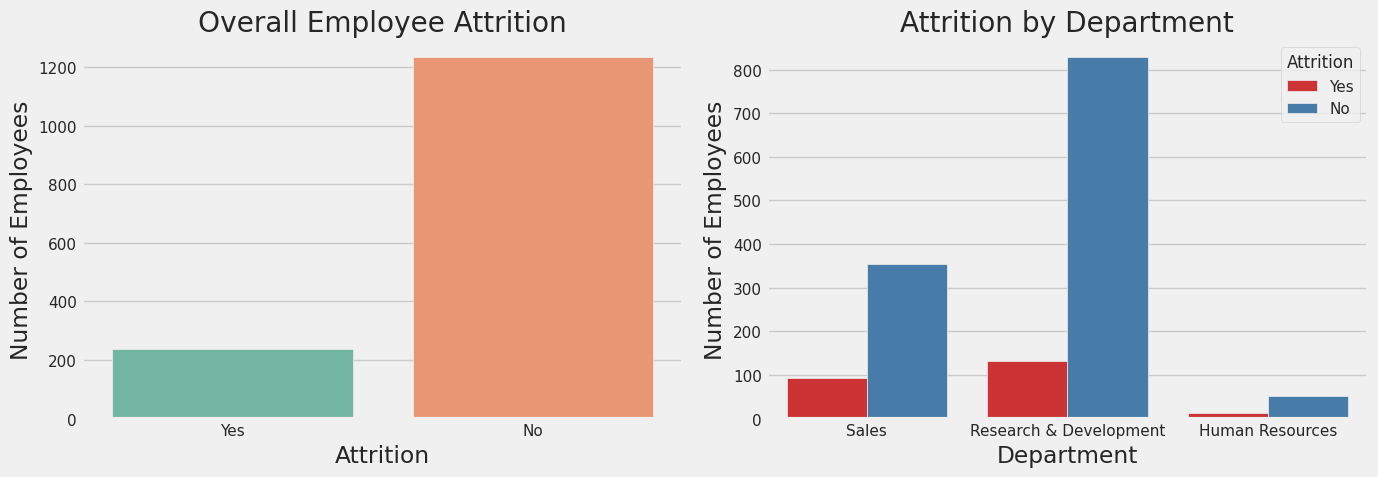

In [4]:
# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Chart 1: Overall Attrition
sns.countplot(ax=axes[0], data=df, x='Attrition', palette='Set2')
axes[0].set_title('Overall Employee Attrition')
axes[0].set_ylabel('Number of Employees')

# Chart 2 : Attrition by Department
sns.countplot(ax=axes[1], data=df, x='Department', hue='Attrition', palette='Set1')
axes[1].set_title('Attrition by Department')
axes[1].set_ylabel('Number of Employees')

plt.tight_layout()
plt.show()

### EDA Insight 1: Attrition Overview & Department
* **Imbalanced Target:** Most employees in this dataset stay. Only about 16% of the workforce left the company. 
* **Departmental Impact:** While Research & Development has the highest absolute number of resignations (due to being the largest department), the **Sales** department appears to have a higher *turnover rate* relative to its size.

Next, we will analyze numerical factors: Does age or salary impact who leaves?

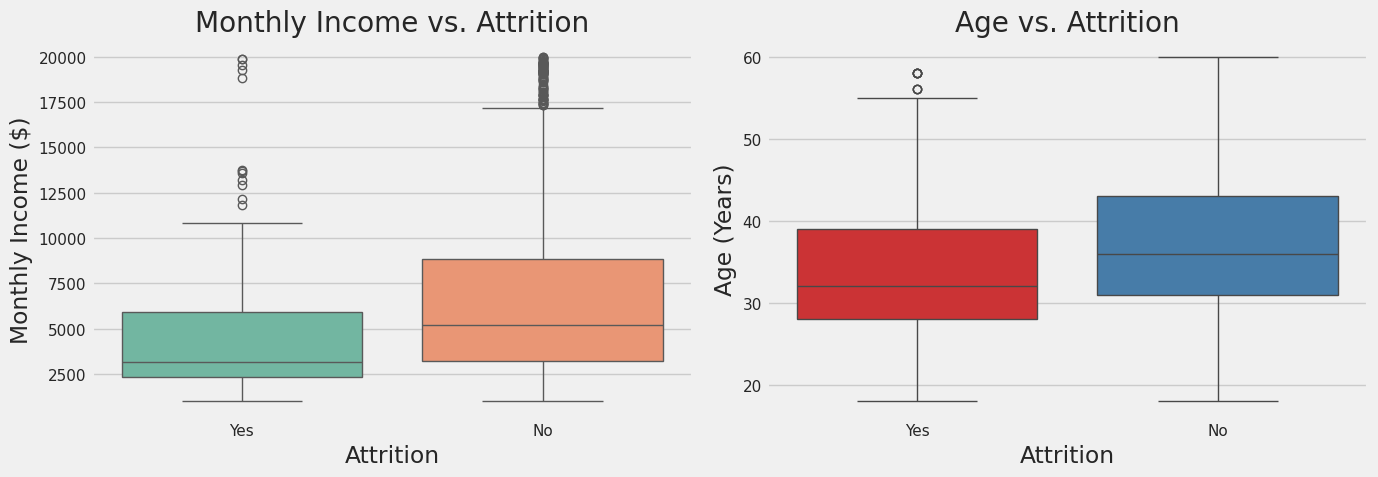

In [5]:
# Create another figure with 2 subplots side-by-side
fig, axes = plt.subplots(1,2, figsize=(14, 5))

# Chart 3: Monthly Income vs Attrition
sns.boxplot(ax=axes[0], data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette='Set2', legend=False)
axes[0].set_title('Monthly Income vs. Attrition')
axes[0].set_ylabel('Monthly Income ($)')

# Chart 4: Age vs Attrition
sns.boxplot(ax=axes[1], data=df, x='Attrition', y='Age', hue='Attrition', palette='Set1', legend=False)
axes[1].set_title('Age vs. Attrition')
axes[1].set_ylabel('Age (Years)')

plt.tight_layout()
plt.show()

### EDA Insight 2: Age and Income
By plotting numerical variables against our target, clear patterns emerge:
* **Income:** Employees who leave tend to have notably lower median monthly incomes than those who stay.
* **Age:** Younger employees show higher attrition rates, with the median age of departing employees hovering around 31-32 years old.

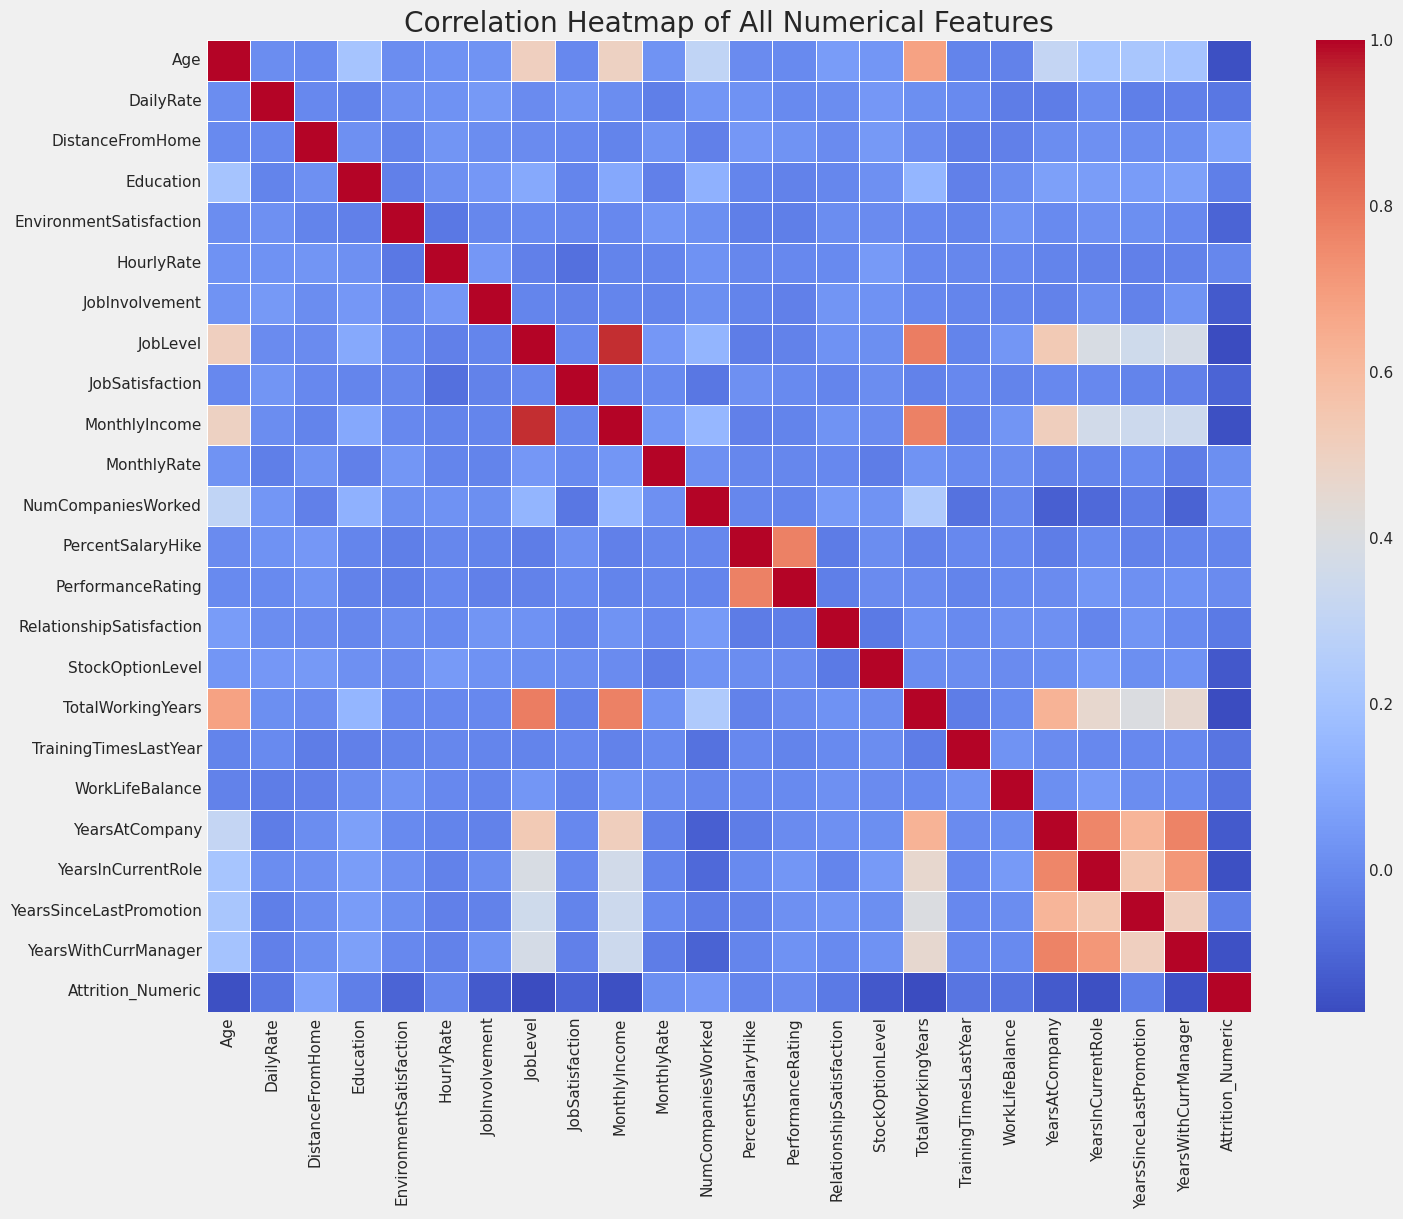

Top factors correlated with Attrition:
Attrition_Numeric     1.000000
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
HourlyRate           -0.006846
Name: Attrition_Numeric, dtype: float64


In [6]:
# 1. Convert 'Attrition' into a number (Yes = 1, No = 0)
# This allows us to see how other numbers correlate with people leaving
df['Attrition_Numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Select ONLY the numerical columns (heatmaps can't calculate text)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 3. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 4. Draw the Heatmap
plt.figure(figsize=(15, 12)) # Make it big so we can read it
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of All Numerical Features')
plt.show()

# 5. Let's print out the top 5 factors most correlated with Attrition
print("Top factors correlated with Attrition:")
print(corr_matrix['Attrition_Numeric'].sort_values(ascending=False).head(6)) 
# (head(6) because the first one will be Attrition_Numeric itself, which is a 1.0 match)

In [7]:
# Let's see what makes people STAY (negative correlation)
print("Factors that make people STAY (Negative Correlation):")
print(corr_matrix['Attrition_Numeric'].sort_values(ascending=True).head(5))

Factors that make people STAY (Negative Correlation):
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205
Name: Attrition_Numeric, dtype: float64


### EDA Insight 3: Correlation Analysis
By converting our target variable to a numeric value, we used a correlation matrix to find mathematical drivers for attrition:
* **What drives people away (Positive Correlation):** `DistanceFromHome` and `NumCompaniesWorked` have the highest positive correlations, suggesting long commutes and a history of job-hopping contribute to turnover.
* **What keeps people (Negative Correlation):** Factors like `TotalWorkingYears`, `JobLevel`, and `Age` are negatively correlated, meaning senior, well-compensated, and older employees are much more likely to stay.
* **Key Takeaway:** No single variable has a strong enough correlation (e.g., > 0.5) to predict attrition on its own. This indicates that employee turnover is a complex, multi-variable problem that would benefit from Machine Learning.

### Final EDA Insight: What Makes Employees Stay?
Looking at the negative correlations, we see that `TotalWorkingYears` (-0.17), `JobLevel` (-0.16), and `MonthlyIncome` (-0.15) are the strongest factors in employee retention. 

**Business Conclusion:** Turnover is primarily concentrated among younger, newer, and lower-paid employees. However, because no single factor has a strong mathematical correlation (all are below 0.20), human behavior here is too complex for simple rules. 

To truly predict attrition, we must move to **Machine Learning**.

In [8]:
# 1. Let's look at how many text columns we still have
categorical_cols = df.select_dtypes(include=['object']).columns
print("Text columns that need converting:\n", categorical_cols)
print("-" * 40)

# 2. Use Pandas to automatically convert these text columns into 1s and 0s
# drop_first=True ensures we don't create mathematically redundant columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Let's see our new Machine Learning-ready dataset!
print(f"Old shape: {df.shape}")
print(f"New ML-ready shape: {df_encoded.shape}\n")

# Display the first 5 rows to see what One-Hot Encoding did
df_encoded.head()

Text columns that need converting:
 Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')
----------------------------------------
Old shape: (1470, 32)
New ML-ready shape: (1470, 46)



,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


### Final Conclusion & Next Steps
In this notebook, we took a raw HR dataset and performed a complete Exploratory Data Analysis to understand employee attrition. 

**Key Business Findings:**
1. Attrition is highest among younger, newer, and lower-paid employees.
2. Employees with longer commutes and a history of working at multiple companies are at a higher risk of leaving.
3. No single factor perfectly predicts attrition, highlighting the complexity of employee retention.

**Machine Learning Readiness:**
To prepare this dataset for predictive modeling, we removed zero-variance columns and performed One-Hot Encoding on all categorical text data. The dataset is now fully numeric and structured, ready to be fed into a classification algorithm (like Random Forest or Logistic Regression) to predict future employee turnover.